#Pinterest Web Scrapping


In [ ]:
!pip install playwright requests nest_asyncio -q
!apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libdrm2 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2 -q
!playwright install chromium
print('✅ Done')

Reading package lists...
Building dependency tree...
Reading state information...
libasound2 is already the newest version (1.2.6.1-1ubuntu1).
libatk-bridge2.0-0 is already the newest version (2.38.0-3).
libatk1.0-0 is already the newest version (2.36.0-3build1).
libxcomposite1 is already the newest version (1:0.4.5-1build2).
libxdamage1 is already the newest version (1:1.1.5-2build2).
libxfixes3 is already the newest version (1:6.0.0-1).
libxkbcommon0 is already the newest version (1.4.0-1).
libxrandr2 is already the newest version (2:1.5.2-1build1).
libcups2 is already the newest version (2.4.1op1-1ubuntu4.16).
libdrm2 is already the newest version (2.4.113-2~ubuntu0.22.04.1).
libgbm1 is already the newest version (23.2.1-1ubuntu3.1~22.04.3).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
✅ Done


In [ ]:
!python pinterest_scraper.py

python3: can't open file '/content/pinterest_scraper.py': [Errno 2] No such file or directory


In [ ]:
import os, time, random, asyncio, requests as req
import nest_asyncio
from playwright.async_api import async_playwright

nest_asyncio.apply()

# ─── CONFIG ───────────────────────────────────────────────
CATEGORIES = {
    'no_makeup':       'women no makeup natural skin',
    'clean_makeup':    'clean girl makeup natural glowy dewy skin',
    'glam_makeup':     'glam makeup look party bold eyes lips',
    'festival_makeup': 'festival makeup rhinestone glitter creative concert',
}
TARGET     = 500
OUTPUT_DIR = '/content/makeup_images'
# ──────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

def upgrade_resolution(url):
    for low in ['/236x/', '/474x/', '/564x/']:
        if low in url:
            return url.replace(low, '/736x/')
    return url

async def collect_image_urls(page, query, target):
    images = set()
    stale_rounds = 0
    print(f'\n🔍 Searching: "{query}"')

    # Retry navigation up to 3 times
    for attempt in range(3):
        try:
            await page.goto(
                f'https://www.pinterest.com/search/pins/?q={query.replace(" ", "+")}',
                wait_until='domcontentloaded',  # faster than networkidle
                timeout=60000,                  # increased to 60s
            )
            break
        except Exception as e:
            print(f'  ⚠️  Attempt {attempt+1} failed: {e}. Retrying...')
            await asyncio.sleep(3)
    else:
        print(f'  ❌ Could not load page for "{query}" after 3 attempts — skipping.')
        return []

    await asyncio.sleep(4)  # extra wait for content to render

    while len(images) < target:
        prev = len(images)

        for el in await page.query_selector_all('img[src*="pinimg.com"]'):
            src = await el.get_attribute('src') or ''
            if 'pinimg.com' in src:
                images.add(upgrade_resolution(src))

        for el in await page.query_selector_all('img[srcset*="pinimg.com"]'):
            srcset = await el.get_attribute('srcset') or ''
            for part in srcset.split(','):
                url = part.strip().split(' ')[0]
                if 'pinimg.com' in url:
                    images.add(upgrade_resolution(url))

        print(f'  📌 {len(images)}/{target} URLs collected')

        if len(images) == prev:
            stale_rounds += 1
            if stale_rounds >= 5:
                print('  ⚠️  No new images — stopping early.')
                break
        else:
            stale_rounds = 0

        await page.evaluate('window.scrollBy(0, window.innerHeight * 2)')
        await asyncio.sleep(random.uniform(2.0, 3.5))  # slightly longer delays

    return list(images)[:target]

def download_images(urls, folder):
    os.makedirs(folder, exist_ok=True)
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36',
        'Referer': 'https://www.pinterest.com/'
    }
    saved = 0
    for i, url in enumerate(urls, 1):
        ext = url.split('.')[-1].split('?')[0].lower() or 'jpg'
        if ext not in ('jpg', 'jpeg'):
            print(f'  ⏭️  Skipped {i} (not jpg/jpeg: .{ext})')
            continue
        path = os.path.join(folder, f'image_{i:03d}.jpg')
        try:
            r = req.get(url, headers=headers, timeout=15)
            if r.status_code == 200 and len(r.content) > 5000:
                with open(path, 'wb') as f:
                    f.write(r.content)
                saved += 1
                print(f'  ✅ {saved}/{len(urls)} → image_{i:03d}.jpg')
            else:
                print(f'  ⚠️  Skipped {i}')
        except Exception as e:
            print(f'  ❌ Failed {i}: {e}')
        time.sleep(random.uniform(0.3, 0.8))
    return saved

async def run_all():
    results = {}
    async with async_playwright() as p:
        browser = await p.chromium.launch(
            headless=True,
            args=['--disable-blink-features=AutomationControlled', '--no-sandbox', '--disable-dev-shm-usage']
        )
        ctx = await browser.new_context(
            user_agent='Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36',
            viewport={'width': 1280, 'height': 900}
        )
        page = await ctx.new_page()
        try:
            for category, query in CATEGORIES.items():
                urls = await collect_image_urls(page, query, TARGET)
                results[category] = urls
        finally:
            await browser.close()
    return results

# ─── RUN ──────────────────────────────────────────────────
all_urls = asyncio.get_event_loop().run_until_complete(run_all())

total_saved = 0
for category, urls in all_urls.items():
    folder = os.path.join(OUTPUT_DIR, category)
    print(f'\n📥 [{category}] Downloading {len(urls)} images...')
    saved = download_images(urls, folder)
    total_saved += saved
    print(f'  💾 {saved} saved → {folder}')

print(f'\n🎉 All done! {total_saved}/600 total images saved to {OUTPUT_DIR}')


🔍 Searching: "women no makeup natural skin"
  📌 19/500 URLs collected
  📌 51/500 URLs collected
  📌 83/500 URLs collected
  📌 115/500 URLs collected
  📌 149/500 URLs collected
  📌 179/500 URLs collected
  📌 215/500 URLs collected
  📌 247/500 URLs collected
  📌 281/500 URLs collected
  📌 311/500 URLs collected
  📌 339/500 URLs collected
  📌 373/500 URLs collected
  📌 403/500 URLs collected
  📌 431/500 URLs collected
  📌 469/500 URLs collected
  📌 503/500 URLs collected

🔍 Searching: "clean girl makeup natural glowy dewy skin"
  📌 27/500 URLs collected
  📌 51/500 URLs collected
  📌 82/500 URLs collected
  📌 116/500 URLs collected
  📌 146/500 URLs collected
  📌 180/500 URLs collected
  📌 216/500 URLs collected
  📌 242/500 URLs collected
  📌 271/500 URLs collected
  📌 301/500 URLs collected
  📌 331/500 URLs collected
  📌 359/500 URLs collected
  📌 387/500 URLs collected
  📌 416/500 URLs collected
  📌 442/500 URLs collected
  📌 469/500 URLs collected
  📌 496/500 URLs collected
  📌 525/500 

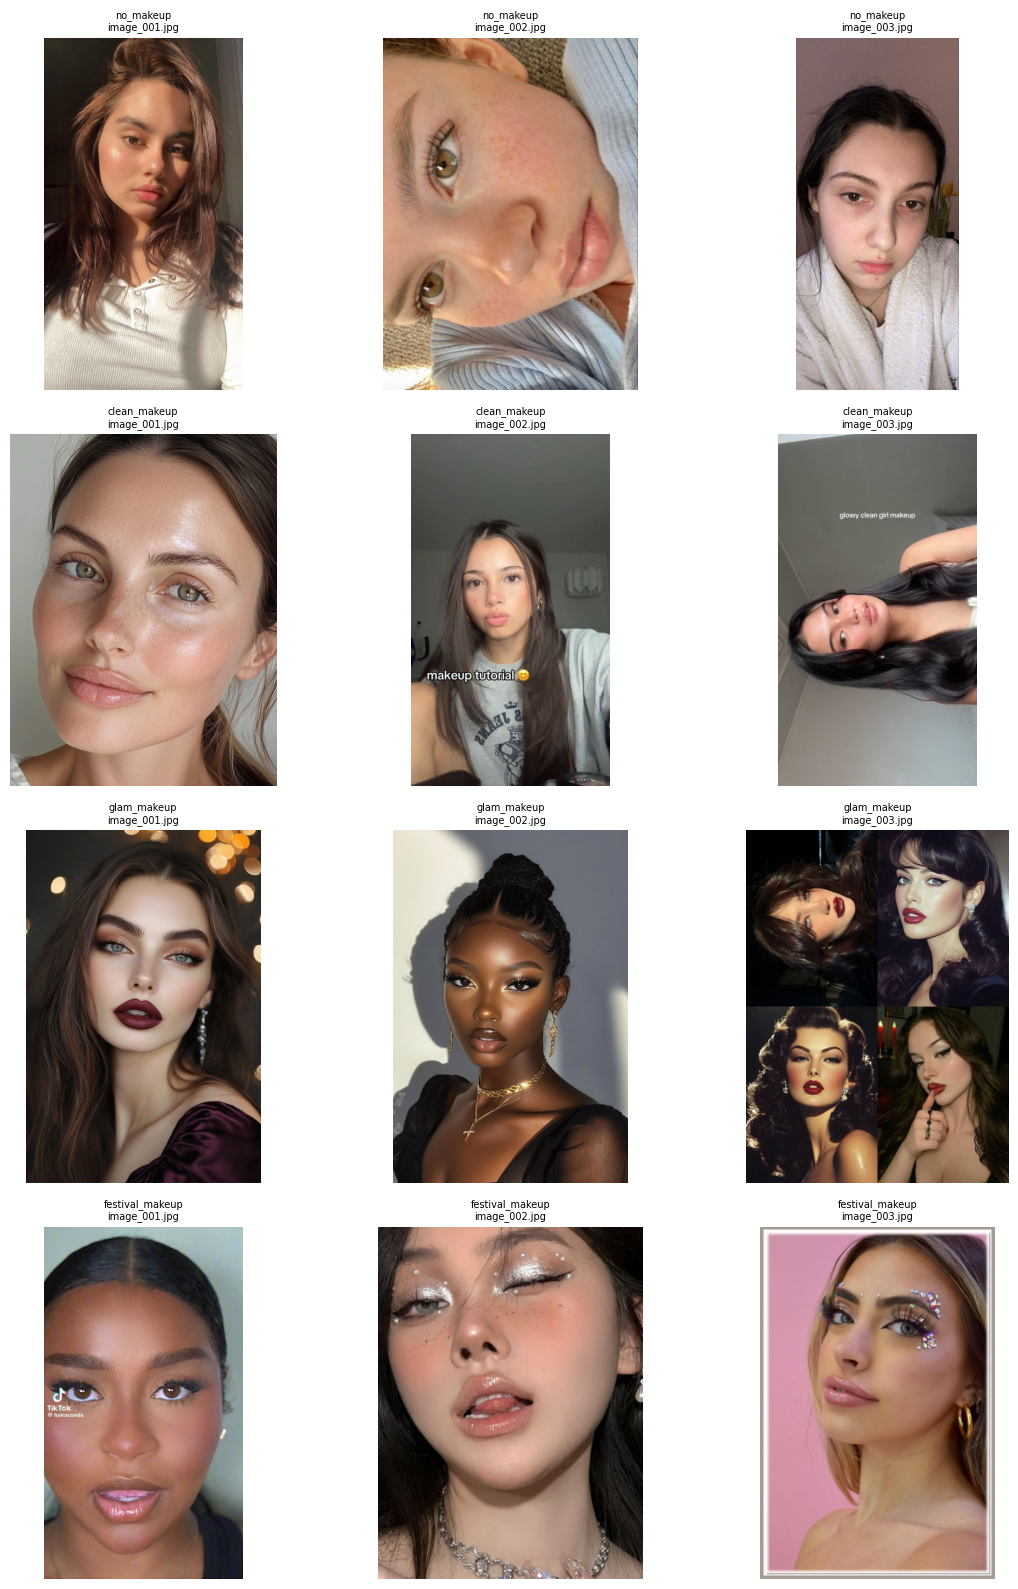

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for row, cat in enumerate(CATEGORIES.keys()):
    files = sorted(glob.glob(f'{OUTPUT_DIR}/{cat}/*'))[:3]
    for col, fp in enumerate(files):
        axes[row][col].imshow(Image.open(fp))
        axes[row][col].axis('off')
        axes[row][col].set_title(f'{cat}\n{os.path.basename(fp)}', fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
import shutil
from google.colab import files

shutil.make_archive('/content/makeup_images', 'zip', OUTPUT_DIR)
print('✅ Zipped!')
files.download('/content/makeup_images.zip')

✅ Zipped!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>